# NT-v2 Iterative MLM: Token-Level Length Change Demo

NT-v2의 BPE 토크나이저는 가변 길이 토큰을 사용한다 (예: `A`, `ACG`, `ACGTAC` 등).
MLM에서 마스킹된 토큰이 **다른 길이의 토큰**으로 예측되면, 디코딩 후 시퀀스의 bp 길이가 변할 수 있다.

이 노트북은 하나의 100bp 시퀀스에 대해 각 iteration에서 **어떤 토큰이 어떻게 변했는지** 토큰 수준으로 추적한다.

| Parameter | Value |
|-----------|-------|
| Sequence length | 100 bp |
| Masking ratio | 0.2 |
| Iterations | 10 |
| Strategy | sampling (T=1.0, top_k=50) |

In [1]:
import sys
sys.path.insert(0, "../01_generate-seq-and-emb/src")

import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from IPython.display import display

from idr.utils import get_device, load_model

/Users/leeminjae/micromamba/envs/dna-fm/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# ── Configuration ──
SEQ_LENGTH = 100
MASK_RATIO = 0.2
ITERATIONS = 10
STRATEGY = "sampling"
TEMPERATURE = 1.0
TOP_K = 50
SEED = 42

In [3]:
# ── Load NT-v2-50m ──
device = get_device()
model = load_model(
    device,
    model_label="NT-v2-50m",
    model_path="InstaDeepAI/nucleotide-transformer-v2-50m-multi-species",
)

PyTorch Version: 2.5.1
Using device: mps
[NT-v2-50m] Loading model...
[NT-v2-50m] Model loaded successfully.


In [4]:
def evolve_step_verbose(model, sequence, mask_ratio, strategy, temperature, top_k):
    """Single MLM step that returns token-level change details."""
    tokenizer = model.tokenizer

    # Tokenize without special tokens
    raw_ids = tokenizer(
        sequence, add_special_tokens=False, truncation=False
    )["input_ids"]
    raw_ids = torch.tensor(raw_ids, device=model.device)

    # Record tokens before masking
    tokens_before = tokenizer.convert_ids_to_tokens(raw_ids.tolist())

    # Build input with special tokens
    window_ids = tokenizer.build_inputs_with_special_tokens(raw_ids.tolist())
    valid_len = len(window_ids)
    input_ids = torch.tensor([window_ids], device=model.device)
    attention_mask = torch.ones((1, valid_len), dtype=torch.long, device=model.device)

    # Find maskable positions (exclude special tokens)
    special_mask = tokenizer.get_special_tokens_mask(
        window_ids, already_has_special_tokens=True
    )
    candidate_indices = [i for i, m in enumerate(special_mask) if m == 0]

    # Select positions to mask
    num_mask = max(1, int(len(candidate_indices) * mask_ratio))
    mask_indices = np.random.choice(candidate_indices, num_mask, replace=False)
    mask_indices = np.sort(mask_indices)

    # Map window positions to raw_ids positions
    window_raw_positions = [i for i, m in enumerate(special_mask) if m == 0]
    local_to_raw = {pos: idx for idx, pos in enumerate(window_raw_positions)}

    # Record which raw positions are masked
    masked_raw_positions = [local_to_raw[int(i)] for i in mask_indices]

    # Apply mask
    input_ids[0, mask_indices] = tokenizer.mask_token_id

    # Forward pass
    with torch.no_grad():
        _, logits = model._compute_logits(
            input_ids, attention_mask=attention_mask, valid_token_len=valid_len
        )

    # Decode predictions
    mask_logits = logits[0, mask_indices, :]
    predicted_ids = model.decode(mask_logits, strategy, temperature, top_k)

    # Update raw_ids
    for local_pos, pred_id in zip(mask_indices, predicted_ids):
        raw_ids[local_to_raw[int(local_pos)]] = pred_id

    # Record tokens after prediction
    tokens_after = tokenizer.convert_ids_to_tokens(raw_ids.tolist())

    # Build change records for masked positions
    changes = []
    for raw_pos in masked_raw_positions:
        tok_before = tokens_before[raw_pos]
        tok_after = tokens_after[raw_pos]
        bp_before = len(tok_before.replace("▁", ""))
        bp_after = len(tok_after.replace("▁", ""))
        changes.append({
            "position": raw_pos,
            "token_before": tok_before,
            "token_after": tok_after,
            "bp_before": bp_before,
            "bp_after": bp_after,
            "bp_delta": bp_after - bp_before,
            "changed": tok_before != tok_after,
        })

    # Decode final sequence
    new_sequence = tokenizer.decode(raw_ids, skip_special_tokens=True).replace(" ", "")

    del input_ids, attention_mask, logits, mask_logits, predicted_ids, raw_ids
    model._clear_cache()

    return new_sequence, changes, tokens_before, tokens_after

In [5]:
# ── Run iterative MLM on a single sequence ──
rng = np.random.default_rng(SEED)
np.random.seed(SEED)

initial_seq = "".join(rng.choice(list("ACGT"), size=SEQ_LENGTH))
print(f"Initial sequence ({len(initial_seq)} bp):")
print(initial_seq)
print()

# Show initial tokenization
init_tokens = model.tokenizer.convert_ids_to_tokens(
    model.tokenizer(initial_seq, add_special_tokens=False)["input_ids"]
)
print(f"Initial tokens ({len(init_tokens)} tokens): {init_tokens}")
print()

# Run iterations
current_seq = initial_seq
step_records = []  # list of (changes_df, tokens_before, tokens_after)
lengths = [len(current_seq)]

for step in range(ITERATIONS):
    new_seq, changes, tok_before, tok_after = evolve_step_verbose(
        model, current_seq, MASK_RATIO, STRATEGY, TEMPERATURE, TOP_K
    )
    step_records.append({
        "changes": pd.DataFrame(changes),
        "tokens_before": tok_before,
        "tokens_after": tok_after,
        "seq_before": current_seq,
        "seq_after": new_seq,
    })
    lengths.append(len(new_seq))
    current_seq = new_seq

    delta = lengths[-1] - lengths[-2]
    delta_str = f"+{delta}" if delta > 0 else str(delta)
    print(f"Step {step + 1:2d}: {lengths[-1]:4d} bp (Δ={delta_str})")

Initial sequence (100 bp):
ATGCCTAGAAGTGTGTGATCGCATTGCTGCCAAGTATTCGATGCATCTGTTACCCAGAGGTGCTCCTCACTACAGCCAGGTCATGGACTTCTTCTCAGGA

Initial tokens (20 tokens): ['ATGCCT', 'AGAAGT', 'GTGTGA', 'TCGCAT', 'TGCTGC', 'CAAGTA', 'TTCGAT', 'GCATCT', 'GTTACC', 'CAGAGG', 'TGCTCC', 'TCACTA', 'CAGCCA', 'GGTCAT', 'GGACTT', 'CTTCTC', 'A', 'G', 'G', 'A']

Step  1:  100 bp (Δ=0)
Step  2:  100 bp (Δ=0)
Step  3:  100 bp (Δ=0)
Step  4:   95 bp (Δ=-5)
Step  5:   95 bp (Δ=0)
Step  6:   95 bp (Δ=0)
Step  7:   95 bp (Δ=0)
Step  8:   95 bp (Δ=0)
Step  9:   95 bp (Δ=0)
Step 10:   95 bp (Δ=0)


In [6]:
# ── Token-level change details per iteration ──
def highlight_length_change(row):
    """Highlight rows where bp length changed."""
    if row["bp_delta"] != 0:
        return ["background-color: #fff3cd"] * len(row)
    return [""] * len(row)


for step_idx, record in enumerate(step_records):
    df = record["changes"]
    len_before = len(record["seq_before"])
    len_after = len(record["seq_after"])
    delta = len_after - len_before

    length_changed = (df["bp_delta"] != 0).any()
    marker = " ⚠️ LENGTH CHANGED" if length_changed else ""

    print(f"\n{'='*60}")
    print(f"Step {step_idx + 1}: {len_before} bp → {len_after} bp (Δ={delta:+d}){marker}")
    print(f"Tokens: {record['tokens_before']}")
    print(f"     →  {record['tokens_after']}")
    print(f"{'='*60}")

    styled = df.style.apply(highlight_length_change, axis=1)
    display(styled)


Step 1: 100 bp → 100 bp (Δ=+0)
Tokens: ['ATGCCT', 'AGAAGT', 'GTGTGA', 'TCGCAT', 'TGCTGC', 'CAAGTA', 'TTCGAT', 'GCATCT', 'GTTACC', 'CAGAGG', 'TGCTCC', 'TCACTA', 'CAGCCA', 'GGTCAT', 'GGACTT', 'CTTCTC', 'A', 'G', 'G', 'A']
     →  ['ACACTT', 'GTGTCT', 'GTGTGA', 'TCGCAT', 'TGCTGC', 'CAAGTA', 'TTCGAT', 'GCATCT', 'GTTACC', 'CAGAGG', 'TGCTCC', 'TCACTA', 'CAGCCA', 'GGTCAT', 'GGACTT', 'TTGCAC', 'A', 'N', 'G', 'A']


,position,token_before,token_after,bp_before,bp_after,bp_delta,changed
0,0,ATGCCT,ACACTT,6,6,0,True
1,1,AGAAGT,GTGTCT,6,6,0,True
2,15,CTTCTC,TTGCAC,6,6,0,True
3,17,G,N,1,1,0,True



Step 2: 100 bp → 100 bp (Δ=+0) ⚠️ LENGTH CHANGED
Tokens: ['ACACTT', 'GTGTCT', 'GTGTGA', 'TCGCAT', 'TGCTGC', 'CAAGTA', 'TTCGAT', 'GCATCT', 'GTTACC', 'CAGAGG', 'TGCTCC', 'TCACTA', 'CAGCCA', 'GGTCAT', 'GGACTT', 'TTGCAC', 'A', 'N', 'G', 'A']
     →  ['ACACTT', 'GTGTCT', 'GTGTGA', 'TCGCAT', 'TGCTGC', 'CATCGG', 'TTCGAT', 'GCATCT', 'GTTACC', 'CAGAGG', 'TGCTCC', 'TCACTA', 'CAGCCA', 'GGTCAT', 'GGACTT', 'N', 'N', 'N', 'G', 'GGGGGG']


,position,token_before,token_after,bp_before,bp_after,bp_delta,changed
0,5,CAAGTA,CATCGG,6,6,0,True
1,15,TTGCAC,N,6,1,-5,True
2,16,A,N,1,1,0,True
3,19,A,GGGGGG,1,6,5,True



Step 3: 100 bp → 100 bp (Δ=+0)
Tokens: ['ACACTT', 'GTGTCT', 'GTGTGA', 'TCGCAT', 'TGCTGC', 'CATCGG', 'TTCGAT', 'GCATCT', 'GTTACC', 'CAGAGG', 'TGCTCC', 'TCACTA', 'CAGCCA', 'GGTCAT', 'GGACTT', 'N', 'N', 'N', 'GGGGGG', 'G']
     →  ['GTCTGT', 'GTGTCT', 'CGAGAC', 'TCGCAT', 'TGCTGC', 'CATCGG', 'TTCGAT', 'GTAGCC', 'GTTACC', 'CAGAGG', 'ATATTA', 'TCACTA', 'CAGCCA', 'GGTCAT', 'GGACTT', 'N', 'N', 'N', 'GGGGGG', 'G']


...

,position,token_before,token_after,bp_before,bp_after,bp_delta,changed
0,1,AAGCGC,GCGCTT,6,6,0,True
1,5,TCTCCT,GCCCTC,6,6,0,True
2,17,N,N,1,1,0,False
3,18,N,N,1,1,0,False



Step 9: 95 bp → 95 bp (Δ=+0)
Tokens: ['AGCCCG', 'GCGCTT', 'CGGGGC', 'CTCCTG', 'ACTTCC', 'GCCCTC', 'TCTCCA', 'GTAGCC', 'CCTCAA', 'CAGAGG', 'CCTCCC', 'TCACTA', 'ACCTGC', 'AGCAGG', 'GGACTT', 'N', 'N', 'N', 'N', 'N']
     →  ['AGCCCG', 'GCGCTT', 'CGGGGC', 'CTCCTG', 'ACTTCC', 'GCCCTC', 'TCTCCA', 'CACTCC', 'CCTCAA', 'CAGAGG', 'CCTCCC', 'CGTCTC', 'ACCTGC', 'GGGGGG', 'GGACTT', 'N', 'N', 'N', 'N', 'N']


,position,token_before,token_after,bp_before,bp_after,bp_delta,changed
0,7,GTAGCC,CACTCC,6,6,0,True
1,11,TCACTA,CGTCTC,6,6,0,True
2,13,AGCAGG,GGGGGG,6,6,0,True
3,17,N,N,1,1,0,False



Step 10: 95 bp → 95 bp (Δ=+0)
Tokens: ['AGCCCG', 'GCGCTT', 'CGGGGC', 'CTCCTG', 'ACTTCC', 'GCCCTC', 'TCTCCA', 'CACTCC', 'CCTCAA', 'CAGAGG', 'CCTCCC', 'CGTCTC', 'ACCTGC', 'GGGGGG', 'GGACTT', 'N', 'N', 'N', 'N', 'N']
     →  ['AGCCCG', 'GGGCGG', 'CGGGGC', 'CTCCTG', 'GGGCGC', 'GCCCTC', 'TCTCCA', 'CACTCC', 'CCTCAA', 'ACCCCC', 'CCTCCC', 'CGTCTC', 'ACCTGC', 'GGGGGG', 'GGACTT', 'G', 'N', 'N', 'N', 'N']


,position,token_before,token_after,bp_before,bp_after,bp_delta,changed
0,1,GCGCTT,GGGCGG,6,6,0,True
1,4,ACTTCC,GGGCGC,6,6,0,True
2,9,CAGAGG,ACCCCC,6,6,0,True
3,15,N,G,1,1,0,True


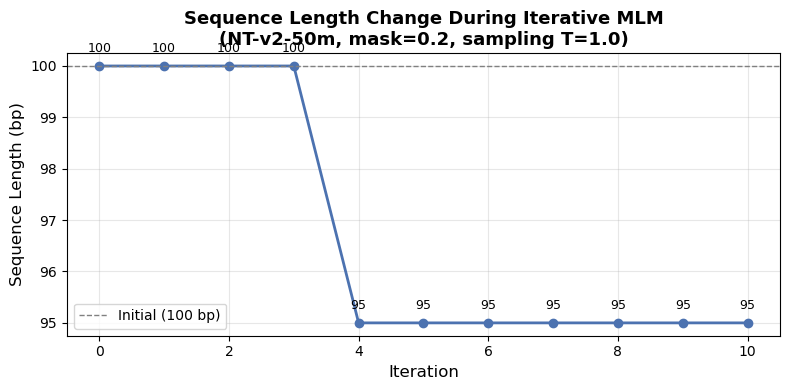

In [7]:
# ── Sequence Length Over Iterations ──
fig, ax = plt.subplots(figsize=(8, 4))

iters = list(range(ITERATIONS + 1))
ax.plot(iters, lengths, marker="o", markersize=6, linewidth=2, color="#4C72B0")

# Annotate length at each point
for i, length in enumerate(lengths):
    ax.annotate(
        str(length),
        (i, length),
        textcoords="offset points",
        xytext=(0, 10),
        ha="center",
        fontsize=9,
    )

ax.axhline(y=SEQ_LENGTH, color="gray", linestyle="--", linewidth=1, label=f"Initial ({SEQ_LENGTH} bp)")
ax.set_xlabel("Iteration", fontsize=12)
ax.set_ylabel("Sequence Length (bp)", fontsize=12)
ax.set_title(
    f"Sequence Length Change During Iterative MLM\n"
    f"(NT-v2-50m, mask={MASK_RATIO}, {STRATEGY} T={TEMPERATURE})",
    fontsize=13, fontweight="bold",
)
ax.xaxis.set_major_locator(ticker.MaxNLocator(integer=True))
ax.yaxis.set_major_locator(ticker.MaxNLocator(integer=True))
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()